<h1>Task #2 – Teen Phone Addiction <h1>
<h2>Course Name: Data Science </h2>
<h3>College: Holon Institute of Technology </br>
   Submitor Name: Omry Abramovich </br>
 </h3>     

# Notebook Setup

## Imports

In [ ]:
## Data Analysis
import pandas as pd

#ML
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score , root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

#Gradient Booster
from xgboost import XGBRegressor

#Visualizations
import matplotlib.pyplot as plt
import seaborn as sns


## Global Variables

In [ ]:
#output
ml_results ={}

#Constants
RND_STATE = 42
FILE_NAME = 'teen_phone_addiction_dataset.csv'
DEBUG = False

 ## Helper Functions

### Data Structure Methods

To keep the code as clean as possible, we will create helper functions that will handle repetitive tasks like model training and evaluation. This will make our main workflow cleaner and easier to read.

In [ ]:
def create_dict_sub_entry(input_dict ,main_key , subkeys, data=None):
  """
    Create or update a nested dictionary structure by adding subkeys under a main key.

    This function ensures that `input_dict` contains a dictionary entry for `main_key`.
    It then either:
      - Populates the subkeys with corresponding values from `data` (if provided).
      - Initializes the subkeys with empty dictionaries (if no `data` is provided).

    Parameters
    ----------
        input_dict (dict): The dictionary to update.
        main_key (str): The key under which the sub-dictionary will be created or updated.
        subkeys (list): A list of subkeys to be added under `main_key`.
        data (list, optional): A list of values corresponding to `subkeys`.
                               If provided, it must have the same length as `subkeys`.

    Returns
    -------
        dict: The updated dictionary `input_dict`
  """
  if main_key not in input_dict.keys():
    input_dict[main_key] = {}

  if data is not None:
    for key, value in zip(subkeys, data):
      if DEBUG:
        print(f"Key: {key}, value: {value}")
      input_dict[main_key][key] = value
  else:
    for key in subkeys:
      if DEBUG:
        print(f"Creating key: {key}")
      input_dict[main_key][key] = {}

In [ ]:
def read_sub_dict(input_dict,main_key,keys_to_read=None):
  """
    Extract values from a nested dictionary under a given main key.

    Parameters
    ----------
    input_dict (dict): The dictionary containing a nested dictionary at `main_key`.
    main_key (str) : The key whose value is expected to be a sub-dictionary. If `None`
                     or not found in `input_dict`, the function returns None.
    keys_to_read (list[str], default = None) : A list of keys to extract from the sub-dictionary. If None,
                                              all values from the sub-dictionary are returned.
    Returns
    -------
    list or None
        - If `main_key` is missing or None → returns None.
        - If `keys_to_read` is None → returns a list of all values from the sub-dictionary.
        - Otherwise → returns a list of values for the requested keys,
          excluding keys not present in the sub-dictionary.
  """
  if main_key is None or main_key not in input_dict:
    return None

  if keys_to_read is None:
    return {key: input_dict[main_key][key] for key in input_dict[main_key].keys()}

  return {key: input_dict[main_key][key]  for key in keys_to_read if key in input_dict[main_key]}


### Machine Learning Functions

In [ ]:
def tune_hyperparameters(default_pipline, params_dict , scoring_method,k_fold,train_set,return_best_parameters = False):
    """
    Finds the best hyperparameters for a model using GridSearchCV.

    Parameters:
    ----------
        default_pipeline (sklear): The model or pipeline to tune.
        params_dict: A dictionary of parameters to test (e.g., {'n_neighbors': [1, 3, 5]}).
        scoring_method: The metric used to score the models (e.g., 'r2').
        k_fold: The number of folds for cross-validation.
        train_set: A tuple containing the training data (X_train, y_train).
        return_best_parameters (bool, optional): If True, also returns the best
        parameters found. Defaults to False.

    Returns:
    --------
        The best performing model. If 'return_best_parameters' is True, it
        returns a tuple of (best_model, best_params).
    """

    x_train_set, y_train_set = train_set
    cv = GridSearchCV(default_pipline,param_grid=params_dict,cv=k_fold,scoring=scoring_method)
    cv.fit(x_train_set, y_train_set)

    if not return_best_parameters:
          return cv.best_estimator_

    return (cv.best_estimator_,cv.best_params_)

In [ ]:
def evaluate_model(pipeline,data_subgroups,return_test_prediction=False,r2_calculation=False,rmse_calculation=False):
  """
    Fit a pipeline, predict on train/val/test, and report metrices.

    Parameters
    ----------
    pipeline : sklearn Pipeline or estimator with fit/predict
    data_subgroups : dict which contains train/val/test tuples (X, Y)
    r2_calculation: bool, default=False
    rmse_calculation: bool, default=False

    Returns
    -------
    pipeline, scores_r2, scores_rmse, y_test_pred
      - pipeline: a fitted pipeline for further analysis.
      - scores_r2 (Optional): dict with R^2 scores for train/validation/test
      - scores_rmse (Optional): dict with rmse scores for train/validation/test
      - y_test_pred (Optional): The predictions generated by the model on the test set.
    """
  #Unpackes the tuples
  x_train, y_train = data_subgroups['train']
  x_val, y_val = data_subgroups['validation']
  x_test, y_test = data_subgroups['test']

  #Training the model
  pipeline.fit(x_train,y_train)

  #Predictions
  y_train_pred = pipeline.predict(x_train)

  y_val_pred = pipeline.predict(x_val)

  y_test_pred = pipeline.predict(x_test)

  # Prediction scores
  r2_train, rmse_train = score_results(r2_calculation,rmse_calculation,true_data=y_train,predicted_data=y_train_pred)
  r2_val, rmse_val = score_results(r2_calculation,rmse_calculation,true_data=y_val,predicted_data=y_val_pred)
  r2_test, rmse_test = score_results(r2_calculation,rmse_calculation,true_data=y_test,predicted_data=y_test_pred)

  #Packing the results
  scores_r2 = {'train':r2_train,'val':r2_val,'test':r2_test}
  scores_rmse = {'train':rmse_train,'val':rmse_val,'test':rmse_test}

  #Return options
  if return_test_prediction:
    return (pipeline,scores_r2,scores_rmse, y_test_pred)

  return (pipeline,scores_r2,scores_rmse)


In [ ]:
def score_results(r2_calculation=True,rmse_calculation=False,true_data=None,predicted_data=None):
    """
      Calculate evaluation metrics (R^2 and/or RMSE) for model predictions.

      Parameters
      ----------
      r2_calculation : bool, default=True
          If True, compute the coefficient of determination (R^2 score).
      rmse_calculation : bool, default=False
          If True, compute the root mean squared error (RMSE).
      true_data : Ground truth (correct) target values.
      predicted_data :Estimated target values returned by the model.

      Returns
      -------
      tuple
          A 2-tuple `(r2_score_value, rmse_score_value)`:
          - r2_score_value : float or None
              The R² score if `r2_calculation=True` and data is provided, otherwise None.
          - rmse_score_value : float or None
              The RMSE if `rmse_calculation=True` and data is provided, otherwise None.
    """

    if (true_data is not None) and (predicted_data is not None):

        #R^2 calculation
        if r2_calculation:
            score_r2 = r2_score(true_data,predicted_data)
        else:
            score_r2 = None

        #RMSE calculation
        if rmse_calculation:
            rmse_score = root_mean_squared_error(true_data,predicted_data)
        else:
            rmse_score = None
        return (score_r2,rmse_score)
    return (None,None)

# Introduction

Smartphones are an important part of teenagers’ daily lives, but overuse can lead to addiction, affecting sleep, studies, and overall well-being. In this project, we analyze data from 3,000 students to explore phone usage patterns and their connection to addiction levels. Using data analysis and machine learning models, we aim to identify the main factors that influence addiction and predict its severity. We begin by reading and exploring the dataset.

In [ ]:
data = pd.read_csv(FILE_NAME)
data.head(5)

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


# Dataset Overview And Statistical Overview

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3000 non-null   int64  
 1   Name                    3000 non-null   object 
 2   Age                     3000 non-null   int64  
 3   Gender                  3000 non-null   object 
 4   Location                3000 non-null   object 
 5   School_Grade            3000 non-null   object 
 6   Daily_Usage_Hours       3000 non-null   float64
 7   Sleep_Hours             3000 non-null   float64
 8   Academic_Performance    3000 non-null   int64  
 9   Social_Interactions     3000 non-null   int64  
 10  Exercise_Hours          3000 non-null   float64
 11  Anxiety_Level           3000 non-null   int64  
 12  Depression_Level        3000 non-null   int64  
 13  Self_Esteem             3000 non-null   int64  
 14  Parental_Control        3000 non-null   

- The dataset contains 3000 samples.
- There are 24 features in total:

  - 3 Identifiers without predictive power:
    - ID
    - Name
    - Location

  - 18 numerical features:
    - 9 of them are integers
    - 9 of them are floats
  - 3 categorial features:
    -  Gender
    -  School Grade
    -  Phone Usage Purpose
- Target column (Addiction_Level) – numerical, severity of addiction (scale, with 10 = high addiction)


- All columns contain 3000 non-null values, meaning there are no missing values.

We will remove the unpredictive features

In [ ]:
data.drop(columns=['ID','Name','Location'], inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     3000 non-null   int64  
 1   Gender                  3000 non-null   object 
 2   School_Grade            3000 non-null   object 
 3   Daily_Usage_Hours       3000 non-null   float64
 4   Sleep_Hours             3000 non-null   float64
 5   Academic_Performance    3000 non-null   int64  
 6   Social_Interactions     3000 non-null   int64  
 7   Exercise_Hours          3000 non-null   float64
 8   Anxiety_Level           3000 non-null   int64  
 9   Depression_Level        3000 non-null   int64  
 10  Self_Esteem             3000 non-null   int64  
 11  Parental_Control        3000 non-null   int64  
 12  Screen_Time_Before_Bed  3000 non-null   float64
 13  Phone_Checks_Per_Day    3000 non-null   int64  
 14  Apps_Used_Daily         3000 non-null   

Since the target is continuous (1–10 scale) and not a set of discrete categories, this is best framed as a regression problem.

Before modeling, we will first examine the basic statistical information of the dataset.

In [ ]:
data.describe()

,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,15.969667,5.020667,6.489767,74.947333,5.097667,1.040667,5.590000,5.460333,5.546333,0.507333,1.006733,83.093000,12.609333,2.499233,1.525267,1.016333,5.459667,6.015100,8.881900
std,1.989489,1.956501,1.490713,14.684156,3.139333,0.734620,2.890678,2.871557,2.860754,0.500030,0.492878,37.747044,4.611486,0.988201,0.932701,0.648341,2.864572,2.014776,1.609598
min,13.000000,0.000000,3.000000,50.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,20.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,14.000000,3.700000,5.500000,62.000000,2.000000,0.500000,3.000000,3.000000,3.000000,0.000000,0.700000,51.000000,9.000000,1.800000,0.800000,0.500000,3.000000,4.700000,8.000000
50%,16.000000,5.000000,6.500000,75.000000,5.000000,1.000000,6.000000,5.000000,6.000000,1.000000,1.000000,82.000000,13.000000,2.500000,1.500000,1.000000,5.000000,6.000000,10.000000
75%,18.000000,6.400000,7.500000,88.000000,8.000000,1.500000,8.000000,8.000000,8.000000,1.000000,1.400000,115.250000,17.000000,3.200000,2.200000,1.500000,8.000000,7.400000,10.000000
max,19.000000,11.500000,10.000000,100.000000,10.000000,4.000000,10.000000,10.000000,10.000000,1.000000,2.600000,150.000000,20.000000,5.000000,4.000000,3.000000,10.000000,14.000000,10.000000


We now turn to the distribution of the dataset by each categorial feature to get a better understanding about the sample composition.
We will start with gender distribution

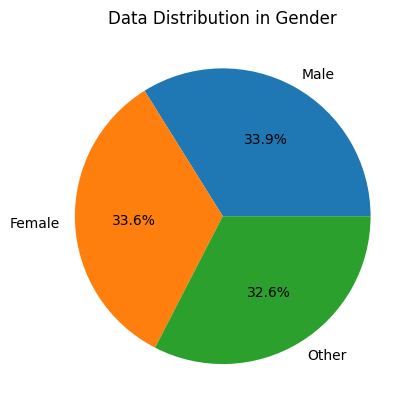

,count
Gender,
Male,1016
Female,1007
Other,977


In [ ]:
gender_counts = data['Gender'].value_counts()
#Creating pie chart
plt.pie(  gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title('Data Distribution in Gender')
plt.show()

gender_counts

* Male Samples: 33.86%
* Female Samples: 33.56%
* Other Samples: 32.56%

The dataset is well-balanced across genders, with each group representing roughly one-third of the total sample.


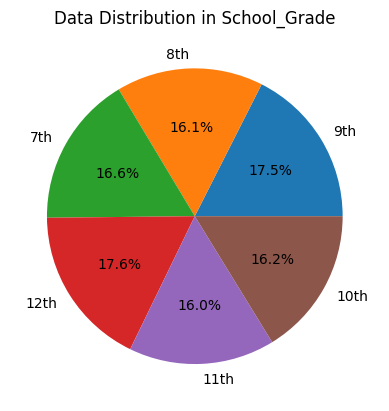

,count
School_Grade,
9th,526
8th,482
7th,497
12th,529
11th,479
10th,487


In [ ]:
school_grade_counts = data['School_Grade'].value_counts().sort_index(ascending=False)
#Creating pie chart
plt.pie(  school_grade_counts, labels=school_grade_counts.index, autopct='%1.1f%%')
plt.title('Data Distribution in School_Grade')
plt.show()
school_grade_counts

The survey was conducted with 3,000 students, ranging from middle to high school levels. We will now examine the distribution across each class.

* 7th grade: 16.56%
* 8th grade: 16.06%
* 9th grade: 17.53%
* 10th grade: 16.23%
* 11th grade: 15.96%
* 12th grade: 17.63%

Each class grade is divided approximately to one sixth of the database


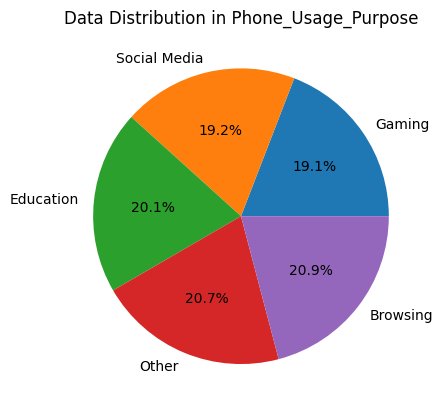

,count
Phone_Usage_Purpose,
Gaming,574
Social Media,575
Education,602
Other,622
Browsing,627


In [ ]:
phone_usage_counts = data['Phone_Usage_Purpose'].value_counts().sort_values(ascending=True)
#Creating pie chart
plt.pie(  phone_usage_counts, labels=phone_usage_counts.index, autopct='%1.1f%%')
plt.title('Data Distribution in Phone_Usage_Purpose')
plt.show()
phone_usage_counts

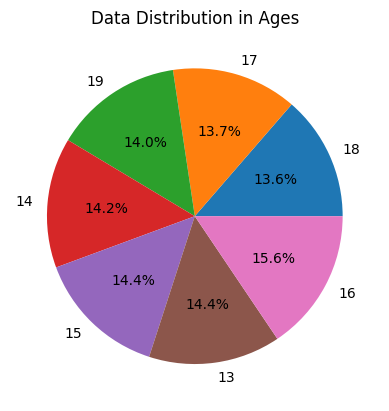

,count
Age,
18,409
17,412
19,421
14,427
15,431
13,433
16,467


In [ ]:
age_counts = data['Age'].value_counts().sort_values(ascending=True)
#Creating pie chart
plt.pie(  age_counts, labels=age_counts.index, autopct='%1.1f%%')
plt.title('Data Distribution in Ages')
plt.show()

age_counts

To sum up, our dataset contains 21 features (after removal of three uninformative ones) . Eighteen of them are numbers, and the rest are categorial.

Our analysis shows that the data is spread approximately evenly across every category. This is important because it means the model will not be highly biased toward any single group. However, it is still likely that the model will achieve better results for groups with more samples.

# EDA and Feature Engineering

We will start the features engineering by encoding our categorial features with One Hot Encoding

In [ ]:
data = pd.get_dummies(data, columns=['Gender', 'Phone_Usage_Purpose', 'School_Grade'])


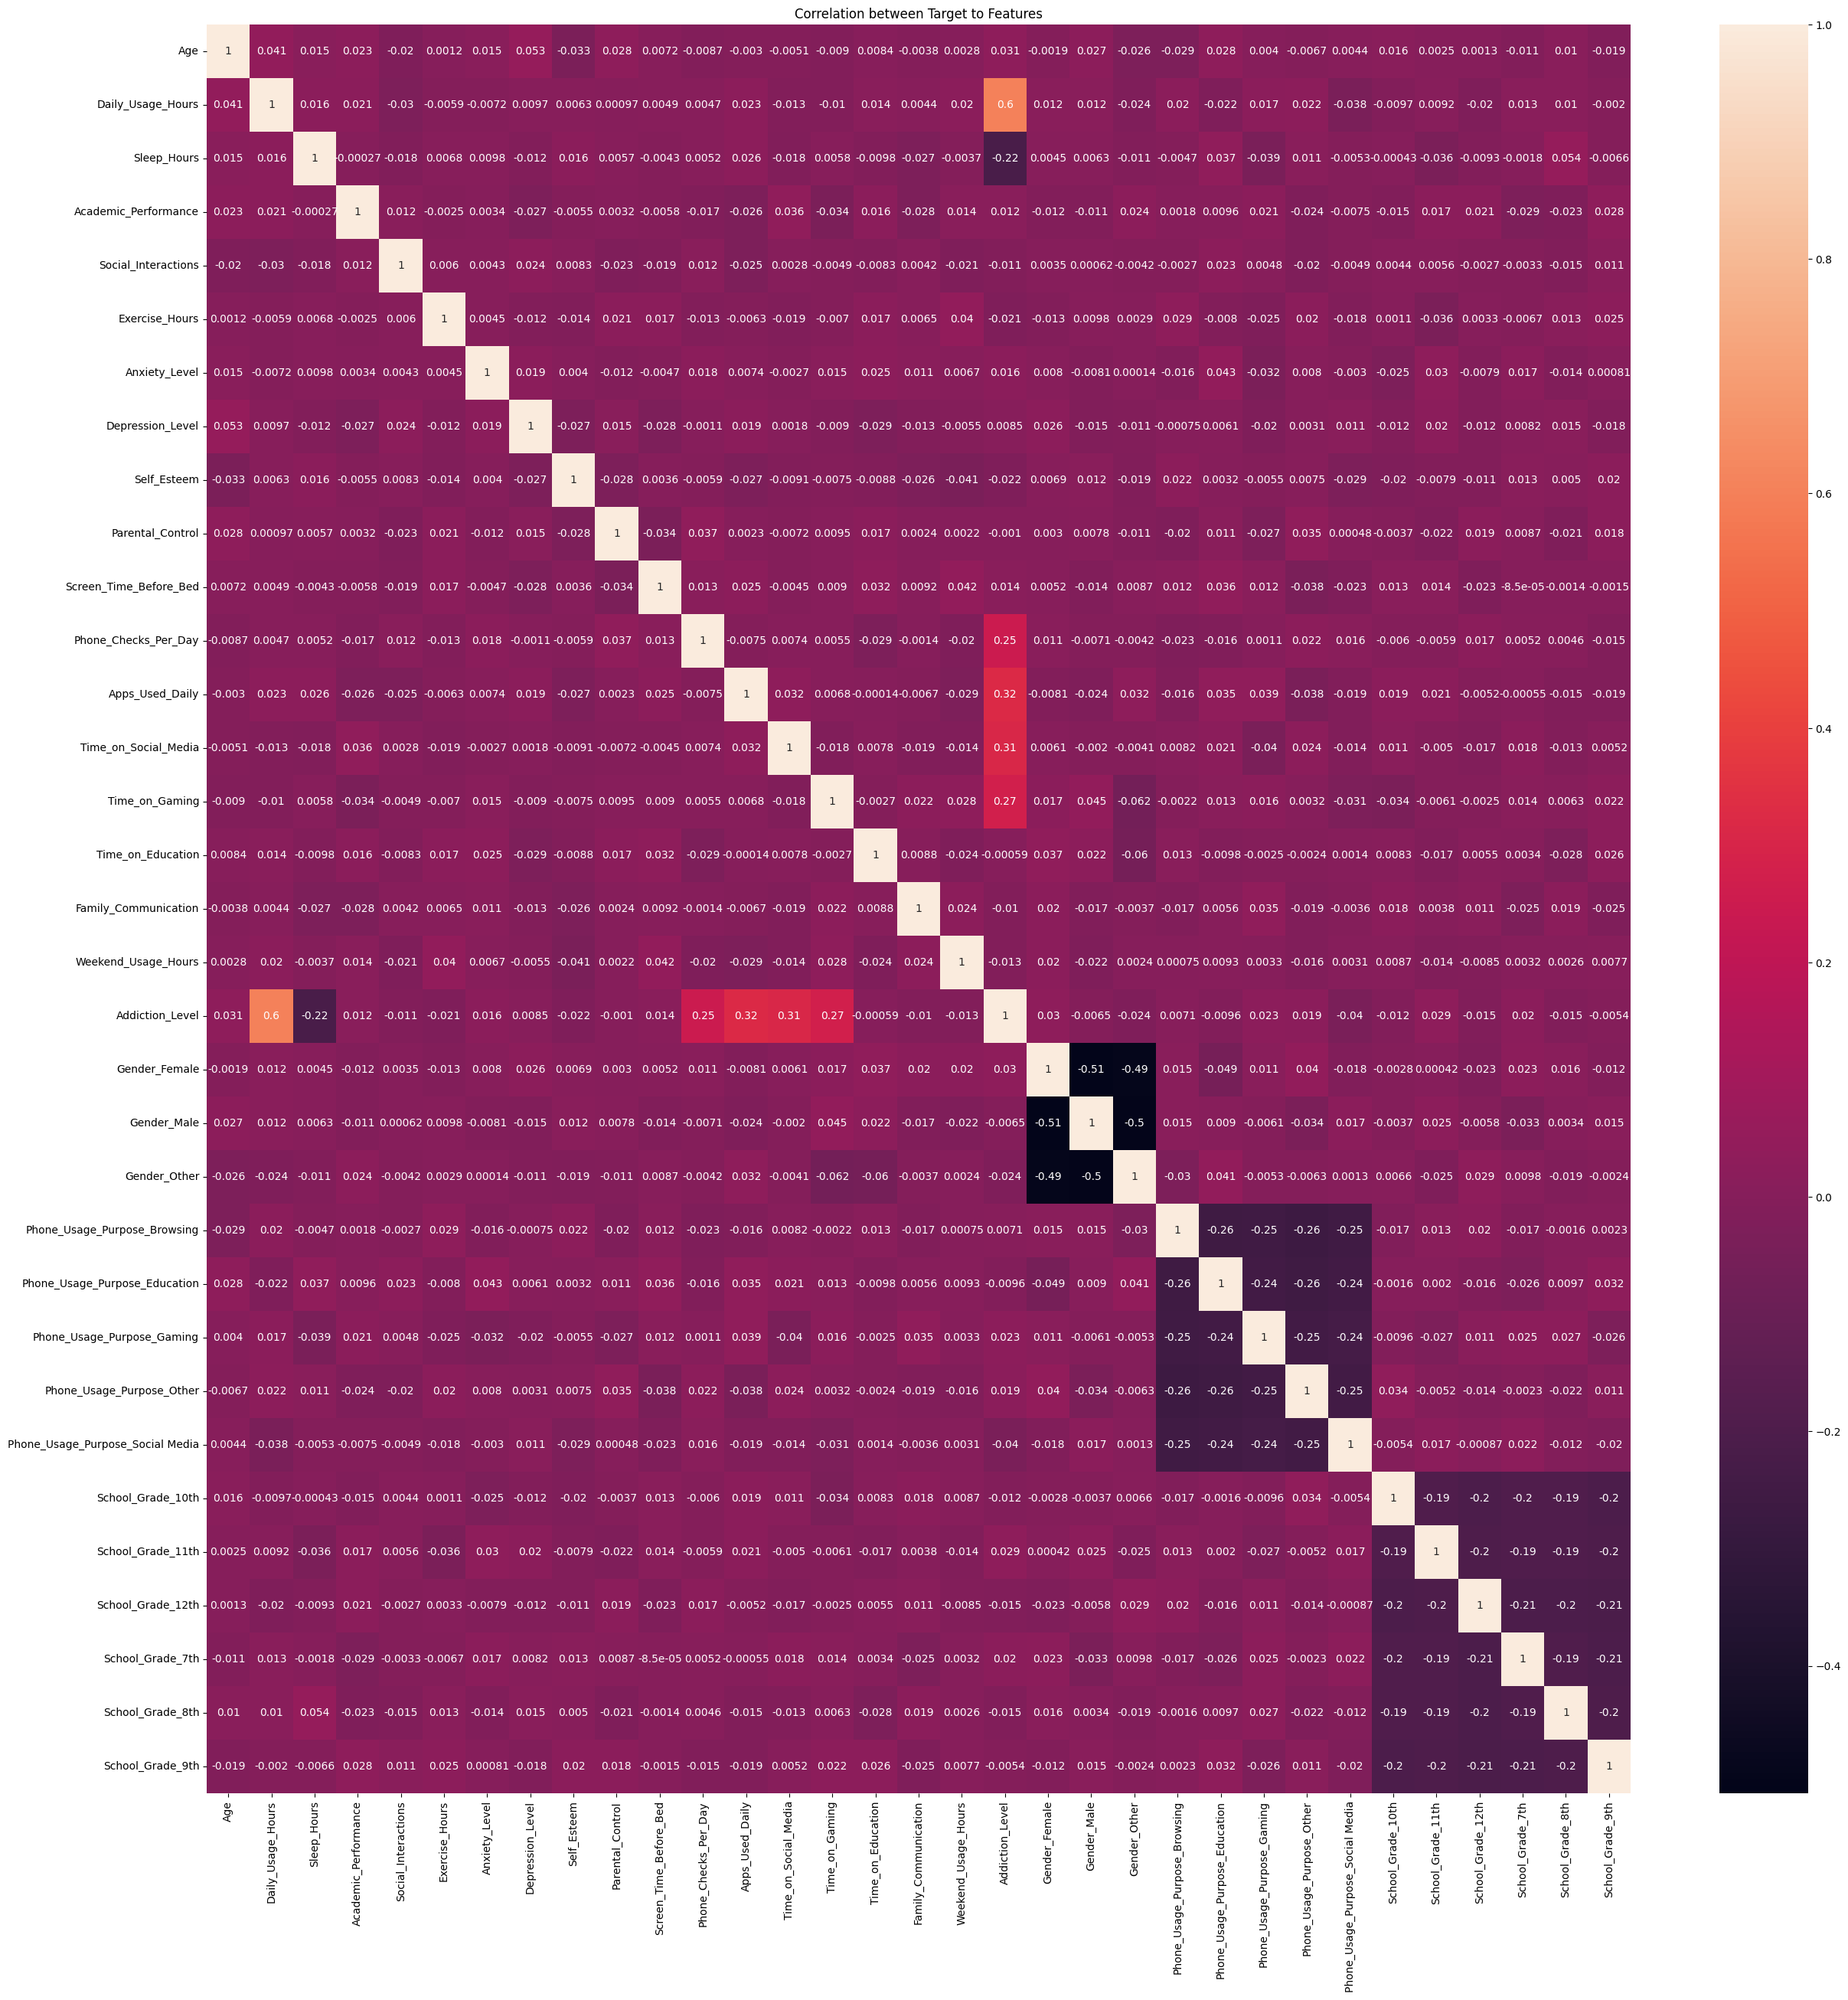

In [ ]:
corrMatrix =data[data.columns.values].corr() # correlation between mean features.
plt.figure(figsize=(30,30))
sns.heatmap(corrMatrix,annot=True)
plt.title("Correlation between Target to Features")
plt.show()

We can learn from this heatmap the following things:
* Sleep hours show weak negative correlation with addiction (r = -0.22). This suggests that students who get more sleep may have a lower risk of developing addictive behavior.

* Screen time before sleep shows almost no correlation with addiction, indicating that it may not have a significant impact on addiction risk.

* Psychological features (such as anxiety, depression, self-esteem) show almost no correlation with addiction, implying that psychological factors alone may not directly drive addiction but could influence it indirectly.

* Exercise (r = -0.021) shows no clear correlation with addiction, indicating it does not have a direct connection to addictive behavior.

We can see that six features have a connection with phone addiction, while the others do not. We can use these relevant features and try to combine them with the less predictive ones in a logical way to create new features.

In [ ]:
# Time Features
data['Daily_Usage_ratio'] = data['Daily_Usage_Hours'] / (data['Daily_Usage_Hours'] +data['Sleep_Hours'] +data['Exercise_Hours'])
data['Time_Spent_On_Entertainment'] = data['Time_on_Gaming'] + data['Time_on_Social_Media']

# Psychological Features
data['Depression_x_Social'] = data['Depression_Level'] * data['Time_on_Social_Media']
data['Depression_x_Gaming'] = data['Depression_Level'] * data['Time_on_Gaming']
data['Self_Esteem_x_Gaming'] = data['Self_Esteem'] * data['Time_on_Gaming']
data['Self_Esteem_x_Social'] = data['Self_Esteem'] * data['Time_on_Social_Media']
data['Anxiety_x_Gaming'] = data['Anxiety_Level'] * data['Time_on_Gaming']
data['Anxiety_x_Social'] = data['Anxiety_Level'] * data['Time_on_Social_Media']


Newly Engineered Features:
* Daily_Usage_ratio - measures the proportion of the day a student spends on hia phone.
* Time_Spent_On_Entertainment - measures the time that the student played or scrolled in social media.
* Depression_x_Social - measures the interaction between depression and time on social media.
* Depression_x_Gaming - measures the interaction between depression and time that the student played on his phone.
* Self_Esteem_x_Social - measures the interaction between self esteem and time on social media.
* Self_Esteem_x_Gaming - measures the interaction between self esteem and time that the student played on his phone.
* Anxiety_x_Social - measures the interaction between anxiety and time on social media.
* Anxiety_x_Gaming - measures the interaction between anxiety and time that the student played on his phone.



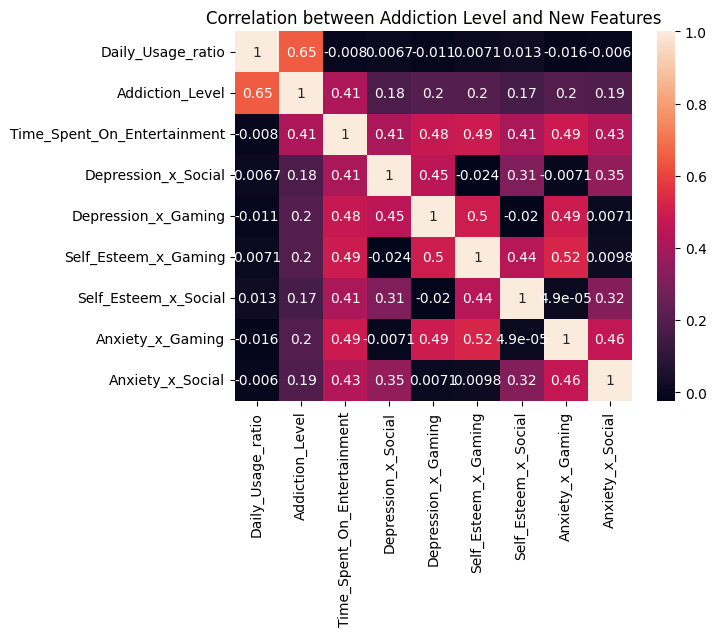

In [ ]:

# Create the heatmap plot
corr_new_features = ['Daily_Usage_ratio','Addiction_Level','Time_Spent_On_Entertainment','Depression_x_Social','Depression_x_Gaming'
                  ,'Self_Esteem_x_Gaming','Self_Esteem_x_Social','Anxiety_x_Gaming','Anxiety_x_Social']

corrMatrix = data[corr_new_features].corr() # correlation between engineered features and phone addiction level.
sns.heatmap(corrMatrix,annot=True)
plt.title("Correlation between Addiction Level and New Features")
plt.show()


Time  features:

* Daily_Usage_ratio shows the strongest positive correlation with Addiction_Level (r = 0.65), indicating it may be a key predictor of phone addiction.

* Time_Spent_On_Entertainment has a moderete positive correlation (r = 0.41) with phone addiction.

Psychological features:

The psychological interactions features show weak positive correlation with phone addiction.
* Self_Esteem_x_Social showed the weakest correlation (r = 0.17)
* Depression_x_Social showed the 2nd weakest correlation (r = 0.18)
* Anxiety_x_Social showed the 3rd weakest correlation (r = 0.19)
* Anxiety_x_Social,Self_Esteem_x_Gaming, and Depression_x_Gaming showed same highest correlation (r = 0.2) in this category.



* These psychological features are modereatly correlated with each other (0.4–0.5), indicating they reflect related emotional or mental health patterns.

The analysis clearly indicates that time-related features are more strongly associated with phone addiction than the psychological interaction features. Daily_Usage_ratio stands out as a particularly powerful predictor.

Now, we can include the six immediate features and then evaluate which of them can be removed based on their contribution.

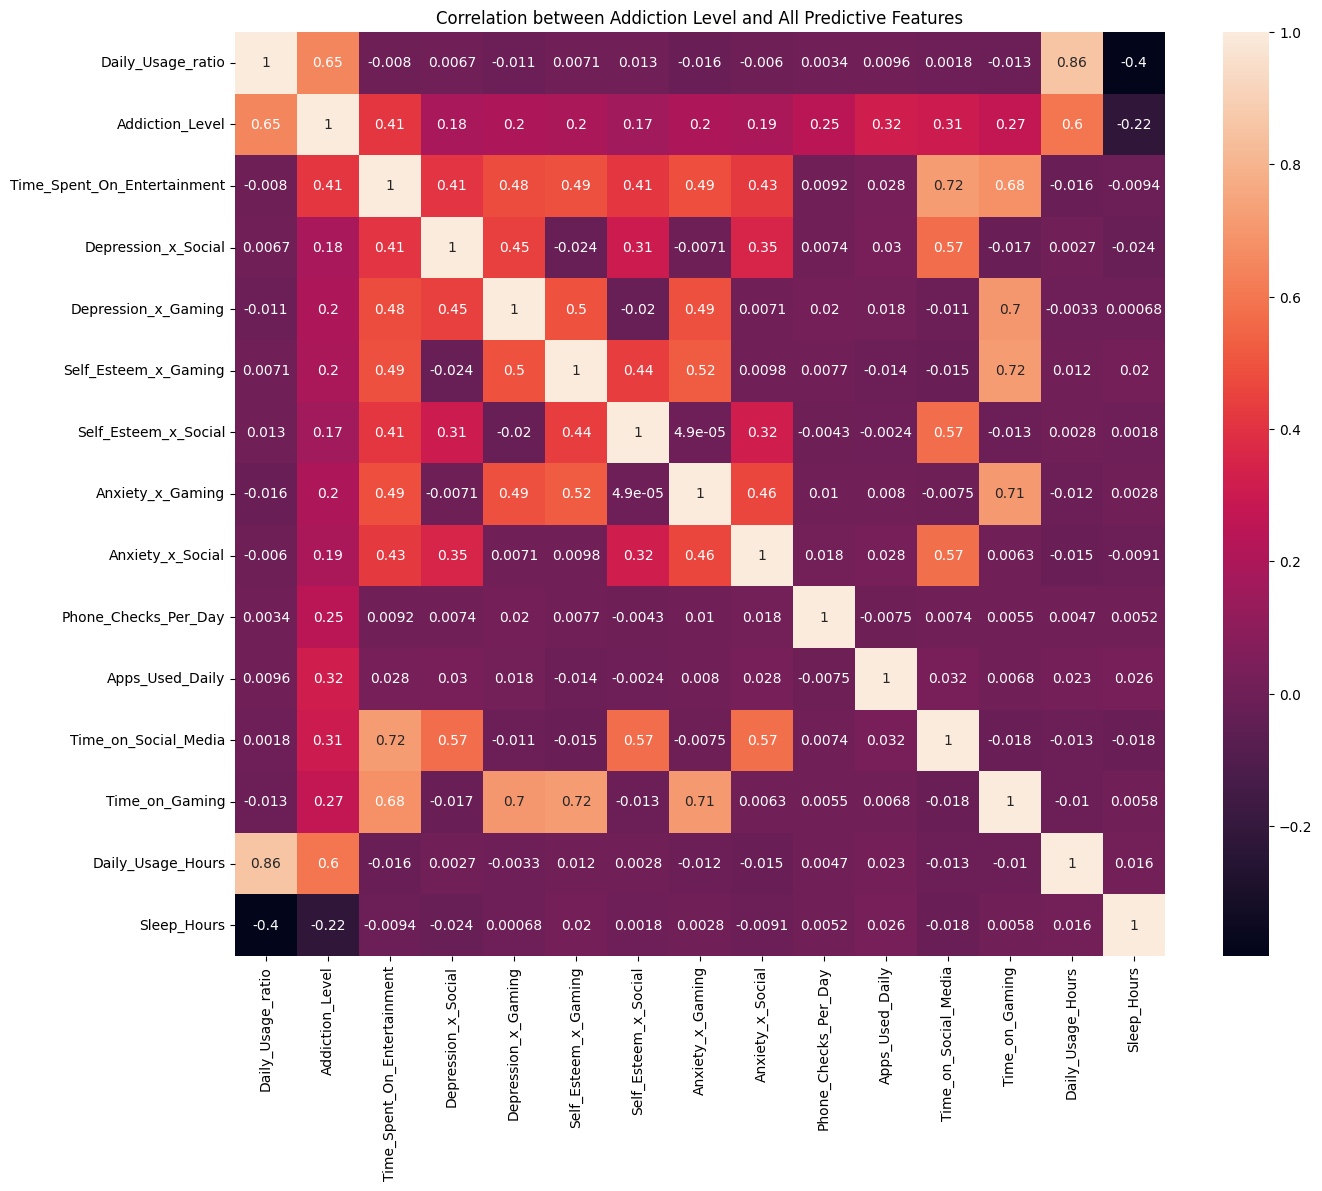

In [ ]:
# Create the heatmap plot
corr_features = corr_new_features +['Phone_Checks_Per_Day','Apps_Used_Daily','Time_on_Social_Media','Time_on_Gaming','Daily_Usage_Hours','Sleep_Hours']
corrMatrix = data[corr_features].corr() # correlation between mean features.
plt.figure(figsize=(15,12))
sns.heatmap(corrMatrix,annot=True)
plt.title("Correlation between Addiction Level and All Predictive Features")
plt.show()


* Daily_Usage_ratio has the strongest positive correlation with Addiction_Level (r = 0.65), making it a key predictor.
* Daily_Usage_Hours also shows a strong positive correlation with addiction (r = 0.60) and is highly correlated with Daily_Usage_ratio (r = 0.86), suggesting one of them is redundant.

* Phone_Checks_Per_Day, Apps_Used_Daily, Time_on_Social_Media, and Time_on_Gaming have weak-to-moderate positive correlations with addiction (r = 0.25–0.32).

* Time_on_Gaming and Time_on_Social_Media have lower correlation alone rather than combined.

Conclusions:
* We can remove Daily_Usage_Hours because Daily_Usage_ratio has a stronger correlation with addiction, making Daily_Usage_Hours redundant.

* Time_Spent_On_Entertainment is a better predictor and we are able to remove Time_on_Gaming and Time_on_Social_Media.


In [ ]:
features_to_drop = ['Daily_Usage_Hours','Time_on_Gaming','Time_on_Social_Media']
corr_features = [feature for feature in corr_features if feature not in features_to_drop]
data.drop(columns=features_to_drop,inplace=True)



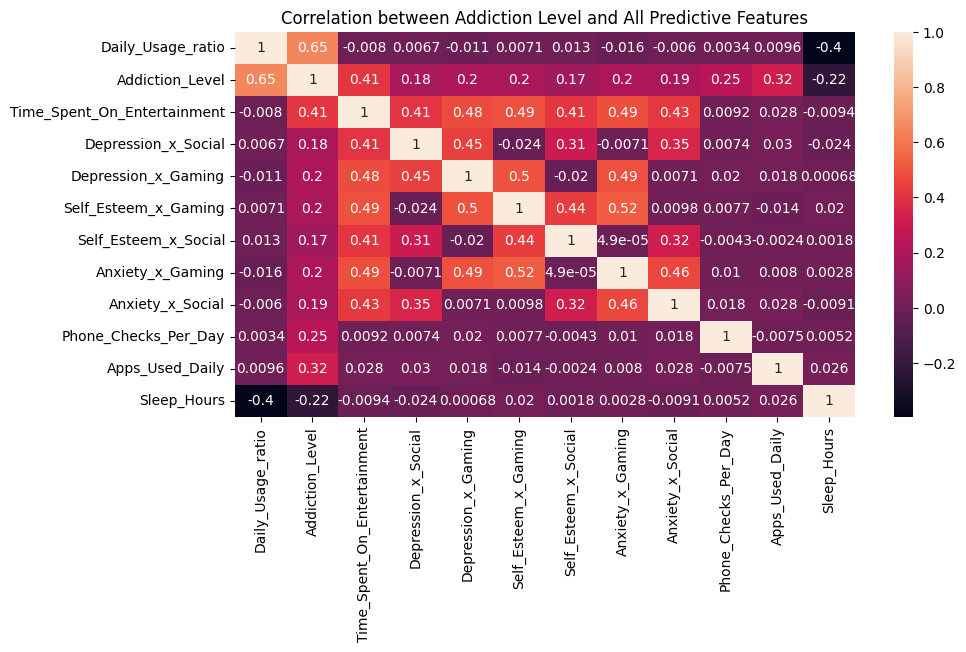

In [ ]:
corrMatrix = data[corr_features].corr()
plt.figure(figsize=(10,5))

sns.heatmap(corrMatrix,annot=True)
plt.title("Correlation between Addiction Level and All Predictive Features")
plt.show()

After identifying which features have the best prediction power, we can remove the rest of the features from the dataset

In [ ]:
features_to_drop = [col for col in data.columns if col not in corr_features ]
print(features_to_drop)
 #Saving the important features inside new dataframe and keeping the rest inside the main dataframe.
clean_data = data.drop(columns=features_to_drop,inplace=False).copy()
clean_data

['Age', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Time_on_Education', 'Family_Communication', 'Weekend_Usage_Hours', 'Gender_Female', 'Gender_Male', 'Gender_Other', 'Phone_Usage_Purpose_Browsing', 'Phone_Usage_Purpose_Education', 'Phone_Usage_Purpose_Gaming', 'Phone_Usage_Purpose_Other', 'Phone_Usage_Purpose_Social Media', 'School_Grade_10th', 'School_Grade_11th', 'School_Grade_12th', 'School_Grade_7th', 'School_Grade_8th', 'School_Grade_9th']


,Sleep_Hours,Phone_Checks_Per_Day,Apps_Used_Daily,Addiction_Level,Daily_Usage_ratio,Time_Spent_On_Entertainment,Depression_x_Social,Depression_x_Gaming,Self_Esteem_x_Gaming,Self_Esteem_x_Social,Anxiety_x_Gaming,Anxiety_x_Social
0,6.1,86,19,10.0,0.392157,5.3,10.8,5.1,13.6,28.8,17.0,36.0
1,6.5,96,9,10.0,0.458333,5.1,7.7,28.0,12.0,3.3,12.0,3.3
2,5.5,137,8,9.2,0.479339,1.8,0.9,4.5,15.0,3.0,3.0,0.6
3,3.9,128,7,9.8,0.360465,4.7,31.0,16.0,4.8,9.3,14.4,27.9
4,6.7,96,20,8.6,0.242718,3.5,13.0,4.5,0.9,2.6,0.9,2.6
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,6.4,80,15,9.8,0.348214,4.5,27.0,18.0,3.6,5.4,12.6,18.9
2996,7.3,45,8,5.5,0.330275,3.1,24.8,0.0,0.0,27.9,0.0,24.8
2997,6.5,51,13,6.2,0.329897,2.6,7.2,0.6,1.8,21.6,0.8,9.6
2998,7.5,125,17,10.0,0.465278,4.3,8.5,13.0,23.4,15.3,7.8,5.1


# Preprocessing

In this step, we will prepare the datasets to be used in our models. Specifically, we will create the training set, validation set and the test set:

In [ ]:
X = clean_data.drop(columns='Addiction_Level', inplace=False)
Y = clean_data['Addiction_Level'].copy()
print(f"X: {X.head()}")
print(f"Y: {Y.head()}")


X:    Sleep_Hours  Phone_Checks_Per_Day  Apps_Used_Daily  Daily_Usage_ratio  \
0          6.1                    86               19           0.392157   
1          6.5                    96                9           0.458333   
2          5.5                   137                8           0.479339   
3          3.9                   128                7           0.360465   
4          6.7                    96               20           0.242718   

   Time_Spent_On_Entertainment  Depression_x_Social  Depression_x_Gaming  \
0                          5.3                 10.8                  5.1   
1                          5.1                  7.7                 28.0   
2                          1.8                  0.9                  4.5   
3                          4.7                 31.0                 16.0   
4                          3.5                 13.0                  4.5   

   Self_Esteem_x_Gaming  Self_Esteem_x_Social  Anxiety_x_Gaming  \
0               

The split will be done with the following proportions:

70% for training

15% for validation

15% for testing

In [ ]:
#Data splitting
X_test_val , X_train,Y_test_val ,Y_train = train_test_split(X, Y, test_size=0.7, random_state=RND_STATE) # 70% split to train set and 30% to validation and test
X_val,X_test , Y_val,Y_test = train_test_split(X_test_val, Y_test_val, test_size=0.5, random_state=RND_STATE) #50% split out of remaining 30%

data_subgroups_dict = {"train": (X_train,Y_train),
                  "validation": (X_val,Y_val),
                  "test": (X_test,Y_test)
                 }
print(f"X_train ratio: {round((X_train.shape[0]/3000)*100)}%")
print(f"X_val ratio: {round((X_val.shape[0]/3000)*100)}%")
print(f"X_test ratio: {round((X_test.shape[0]/3000)*100)}%")



X_train ratio: 70%
X_val ratio: 15%
X_test ratio: 15%


# Models Evaluations

## Baseline Model - KNN Regressor

Before training the state-of-the-art (SOTA) model, we first built a baseline model using a KNN regressor. This baseline serves as a performance benchmark that the SOTA model will need to surpass.

<h3>Hyperparameters Tuning</h3>

In [ ]:
#Creating a pipline with deafult configuation
knn = KNeighborsRegressor()
scaler = StandardScaler()
pipeline_baseline = Pipeline([('scaler',scaler),('regressor', knn)])

#Evlauating the best hyperparameters
params = {'regressor__n_neighbors':list(range(1,10)),'regressor__p':[1,2]}
best_estimator, best_param_knn = tune_hyperparameters(pipeline_baseline, params_dict=params,k_fold=5,scoring_method='neg_root_mean_squared_error'
                                ,train_set=data_subgroups_dict['train'],return_best_parameters=True)
print(best_param_knn)

{'regressor__n_neighbors': 6, 'regressor__p': 2}


<h3>Model Evaluation</h3>


In [ ]:
pipeline_baseline, r2_scores,rmse_scores = evaluate_model(best_estimator,data_subgroups=data_subgroups_dict,
                                                          return_test_prediction=False,r2_calculation=True,rmse_calculation=True)

print(f"Train set : R^2  = {r2_scores['train']},  RMSE  = {rmse_scores['train']}")
print(f"Validation set : R^2  = {r2_scores['val']},  RMSE  = {rmse_scores['val']}")
print(f"Test set : R^2  = {r2_scores['test']},  RMSE  = {rmse_scores['test']}")

#Saving the results
create_dict_sub_entry(ml_results,'KNN',['R2','RMSE','best_params'],[
    [r2_scores['train'],r2_scores['val'],r2_scores['test']],[rmse_scores['train'],rmse_scores['val'],rmse_scores['test']],best_param_knn])


Train set : R^2  = 0.8743553248532479,  RMSE  = 0.5601141937613348
Validation set : R^2  = 0.8286460242646417,  RMSE  = 0.6962336949794166
Test set : R^2  = 0.8181743932280315,  RMSE  = 0.7111714384132808


The KNN regressor achieved an r^2 of approximately 0.87 on the training set, with performance dropping to about 0.83 on the validation set and 0.82 on the test set. The corresponding RMSE values were 0.56 (train), 0.70 (validation), and 0.71 (test), indicating that the model’s predictions deviate from the true values by roughly 0.7 units on unseen data. This consistency across splits shows that the model generalizes reasonably well.

The modest drop in performance suggests a limited degree of overfitting, while the higher error values indicate that the model may be underfitting due to the simplicity of KNN in capturing complex patterns.

These results establish the baseline performance that our SOTA model will need to surpass.

## SOTA Model - XGBoost

<h3>Hyperparameters Tuning</h3>

**Note**: This cell may take a couple of minutes to complete. The GridSearchCV is training a large number of models to find the optimal combination of hyperparameters for the XGBoost regressor.

In [ ]:
#Creating a pipline with deafult configuation

xgboost = XGBRegressor()
pipeline_sota = Pipeline([('regressor', xgboost)])

#Evlauating the best hyperparameters
params = {'regressor__n_estimators': [100, 200, 300, 500, 800,1000],
          'regressor__max_depth':list(range(1,5)),
          'regressor__learning_rate':[0.02,0.06,0.08,0.1]
          }
best_estimator, best_param_xgb = tune_hyperparameters(pipeline_sota, params_dict=params,k_fold=5,scoring_method='neg_root_mean_squared_error'
                                ,train_set=data_subgroups_dict['train'],return_best_parameters=True)
print(best_param_xgb)

{'regressor__learning_rate': 0.06, 'regressor__max_depth': 3, 'regressor__n_estimators': 1000}


<h3> Model Evaluation </h3>

In [ ]:
pipeline_sota, r2_scores,rmse_scores, xgb_test_prediction = evaluate_model(best_estimator,data_subgroups=data_subgroups_dict,
                                                                           return_test_prediction=True, r2_calculation=True,rmse_calculation=True)
#Printing the results
print(f"Train set : R^2  = {r2_scores['train']},  RMSE  = {rmse_scores['train']}")
print(f"Validation set : R^2  = {r2_scores['val']},  RMSE  = {rmse_scores['val']}")
print(f"Test set : R^2  = {r2_scores['test']},  RMSE  = {rmse_scores['test']}")


#Saving the results
create_dict_sub_entry(ml_results,'XGBoost',['R2','RMSE','best_param'],[
    [r2_scores['train'],r2_scores['val'],r2_scores['test']],
    [rmse_scores['train'],rmse_scores['val'],rmse_scores['test']],best_param_xgb
  ])


Train set : R^2  = 0.9839195541586487,  RMSE  = 0.20037963313124987
Validation set : R^2  = 0.9368597200145986,  RMSE  = 0.4226308513254036
Test set : R^2  = 0.9422710872004618,  RMSE  = 0.4007222645754565


The XGBoost regressor reached an R^2 of about 0.98 on the training set, with performance slightly lower around 0.94 on both the validation and test sets. The RMSE values were 0.20 for training, 0.42 for validation, and 0.40 for testing, which shows the model makes fairly small prediction errors compared with KNN. Since the results are consistent across datasets, the model appears to generalize well to unseen data. The small drop in performance from training to validation/test points to only minor overfitting, while the strong overall accuracy suggests that XGBoost is capturing the key patterns in the data.

In [ ]:
importances = pipeline_sota.named_steps["regressor"].feature_importances_ # Accessing XGBoot feature importances
feature_names = X.columns.values

feature_importances_df = pd.DataFrame(importances, index=feature_names, columns=['importance']) #Creating a dataframe from the extracted data

# Sort by the 'importance' column
sorted_features = feature_importances_df.sort_values(by='importance', ascending=False)

print(sorted_features)

                             importance
Daily_Usage_ratio              0.432672
Time_Spent_On_Entertainment    0.294349
Apps_Used_Daily                0.151722
Phone_Checks_Per_Day           0.081213
Sleep_Hours                    0.008835
Depression_x_Gaming            0.007987
Anxiety_x_Gaming               0.005219
Anxiety_x_Social               0.004978
Self_Esteem_x_Social           0.004551
Self_Esteem_x_Gaming           0.004445
Depression_x_Social            0.004029


Drawing the data with bars plot

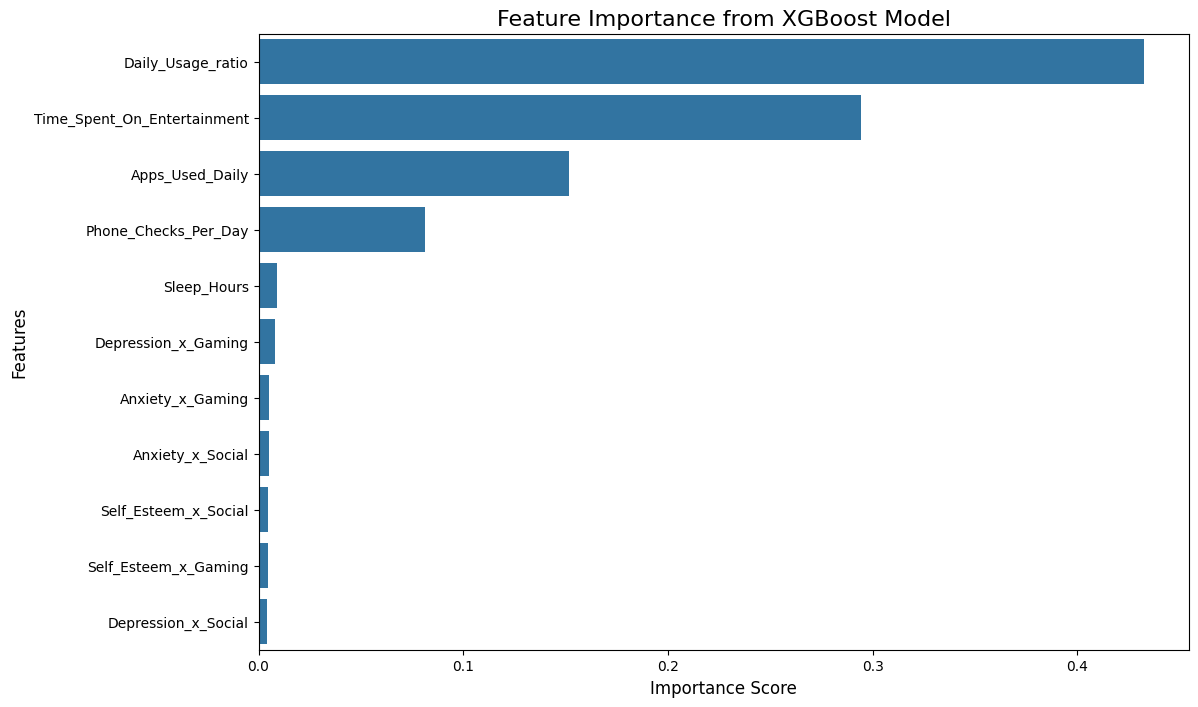

In [ ]:
plt.figure(figsize=(12, 8)) # Adjust size as needed

# Create the bar plot
sns.barplot(x=sorted_features['importance'], y=sorted_features.index)

# Add titles and labels
plt.title('Feature Importance from XGBoost Model', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()


The feature importance analysis showed that Daily_Usage_Ratio, Time_Spent_On_Entertainment, and Apps_Used_Daily were the strongest predictors of phone addiction. Features such as Phone_Checks_Per_Day and Sleep_Hours had moderate influence, while the engineered psychological variables contributed very little to the model.

These findings are consistent with our initial EDA results: students’ behaviors are more directly linked to phone addiction than their psychological self-assessments. They also demonstrate the value of our feature engineering, since the model relied heavily on the newly created features Daily_Usage_Ratio and Time_Spent_On_Entertainment.

When comparing models, XGBoost (R^2 = 0.94, RMSE = 0.40) clearly outperformed the KNN baseline (R^2 = 0.82, RMSE = 0.71) on the test set. This corresponds to roughly a 13.5% improvement in R^2 and a substantial reduction in prediction error, highlighting that XGBoost’s greater complexity and learning ability made it more suitable for this task.

In summary, features capturing behavior and usage patterns proved far more predictive of phone addiction than psychological measures. This pattern was already visible during the EDA, and the modeling results confirmed it. Given XGBoost’s stronger performance, it will be used for all further analysis.

# XGBoost Performance Comparisons

## Data Prepration

The analysis dataframe was created to compare model predictions with the actual test data. It includes demographic details such as Gender, School Grade, and Age for each individual in the test set. Alongside these attributes, the table presents both the True Addiction Level (from the ground truth labels) and the Predicted Addiction Level (from the XGBoost model). This structure makes it easier to evaluate model performance while also examining whether demographic factors influence prediction accuracy.

In [ ]:

original_data = pd.read_csv(FILE_NAME)

analysis_df = pd.DataFrame({
    'Gender': original_data.loc[X_test.index, 'Gender'],
    'School_Grade': original_data.loc[X_test.index, 'School_Grade']
    ,'Ages': original_data.loc[X_test.index,'Age'],
    'True_Addiction_Level': Y_test,
    'Predicted_Addiction_Level': xgb_test_prediction
})
if DEBUG:
  analysis_df


 ## No.1 :  Males vs Females

In [ ]:
#Filter by gender
males_df = analysis_df[analysis_df['Gender'] == 'Male']
females_df =  analysis_df[analysis_df['Gender'] == 'Female']

# Calculate  metrics
r2_males, rmse_male = score_results(r2_calculation=True,rmse_calculation=True,true_data=males_df['True_Addiction_Level'],
                                    predicted_data=males_df['Predicted_Addiction_Level'])
r2_females,rmse_female = score_results(r2_calculation=True,rmse_calculation=True,true_data=females_df['True_Addiction_Level'],
                                    predicted_data=females_df['Predicted_Addiction_Level'])

print(f"Males group evaluation: R^2 = {r2_males}, RMSE = {rmse_male}")
print(f"Females group evaluation: R^2 = {r2_females}, RMSE = {rmse_female}")

#Saving the data
create_dict_sub_entry(ml_results,'gender_comparison',['males','females'],None)
create_dict_sub_entry(ml_results['gender_comparison'],'males',['R2','RMSE'],[r2_males, rmse_male])
create_dict_sub_entry(ml_results['gender_comparison'],'females',['R2','RMSE'],[r2_females,rmse_female])



Males group evaluation: R^2 = 0.9584316958375817, RMSE = 0.3891017220979787
Females group evaluation: R^2 = 0.9215125517233232, RMSE = 0.4117666817763206


The model demonstrated strong performance for both groups. For males, the results showed an R^2 of 0.958 and an RMSE of 0.389, indicating highly accurate predictions with minimal error. For females, the model also performed well, with an R^2 of 0.922 and an RMSE of 0.412. While both groups achieved strong predictive accuracy, the model was slightly more accurate for males, explaining more variance and yielding a lower error rate. Overall, the differences are modest, suggesting the model generalizes well across both groups.

## No.2:  Comparisons Between School Grades

In [ ]:
ml_results['school_grade_comparison'] = {}
for grade, group in analysis_df.groupby('School_Grade'):
    r2, rmse = score_results(r2_calculation=True,rmse_calculation=True,true_data=group['True_Addiction_Level'], predicted_data=group['Predicted_Addiction_Level'])
    print(f"Scores for {grade} class: R^2 = {r2}, RMSE = {rmse} ")
    create_dict_sub_entry(ml_results['school_grade_comparison'],grade,['R2','RMSE'],[r2,rmse])

Scores for 10th class: R^2 = 0.924826586802026, RMSE = 0.49222876262496373 
Scores for 11th class: R^2 = 0.9570621116622956, RMSE = 0.3359064361336464 
Scores for 12th class: R^2 = 0.9539064177253463, RMSE = 0.3521161086573316 
Scores for 7th class: R^2 = 0.934090975474179, RMSE = 0.40698023675178624 
Scores for 8th class: R^2 = 0.9554185836852864, RMSE = 0.3848239087864628 
Scores for 9th class: R^2 = 0.9244559729102368, RMSE = 0.4109386283360744 


The model’s performance across different class levels was consistently strong, with R^2 values above 0.92 in all cases, indicating that it explains more than 92% of the variance in scores. Among the groups, the 11th class showed the highest accuracy (R^2 = 0.957, RMSE = 0.336), followed closely by the 8th (R^2 = 0.955, RMSE = 0.385) and 12th classes (R^2 = 0.954, RMSE = 0.352). The 10th and 9th classes showed comparatively lower performance (R^2 = 0.925, RMSE = 0.49 and 0.411 respectively), while the 7th class achieved intermediate results (R^2 = 0.934, RMSE = 0.407). Overall, the model generalizes well across all grade levels, with the best predictive accuracy observed in higher classes (11th and 12th).

## No.3: Ages 13–14 vs. Ages 17–18

In [ ]:
#Filter the age group of 13 - 14
middle_schooler_df = analysis_df[(analysis_df['Ages'] >= 13) & (analysis_df['Ages'] <= 14)]

#Filter the age group of 17 - 18
high_schooler_df = analysis_df[(analysis_df['Ages'] >= 17) & (analysis_df['Ages'] <= 18)]

# Calculate metrics
middle_schooler_r2, middle_schooler_rmse = score_results(r2_calculation=True,rmse_calculation=True,true_data=middle_schooler_df['True_Addiction_Level'], predicted_data=middle_schooler_df['Predicted_Addiction_Level'])
high_schooler_r2, high_schooler_rmse = score_results(r2_calculation=True,rmse_calculation=True,true_data=high_schooler_df['True_Addiction_Level'], predicted_data=high_schooler_df['Predicted_Addiction_Level'])

print(f"Age group 13-14 evaluation: R^2 = {middle_schooler_r2}, RMSE = {middle_schooler_rmse}")
print(f"Age group 17-18 evaluation: R^2 = {high_schooler_r2}, RMSE = {high_schooler_rmse}")

#Saving the results
ml_results['age_comparison'] = {}
create_dict_sub_entry(ml_results['age_comparison'],'13-14',['R2','RMSE'],[middle_schooler_r2,middle_schooler_rmse])
create_dict_sub_entry(ml_results['age_comparison'],'17-18',['R2','RMSE'],[middle_schooler_r2,middle_schooler_rmse])



Age group 13-14 evaluation: R^2 = 0.9382424246424581, RMSE = 0.4146387361237489
Age group 17-18 evaluation: R^2 = 0.9469307435860438, RMSE = 0.3628073749499187


The model performed well across both age groups. For the 13–14 age group, the evaluation yielded an R^2 of 0.938 with an RMSE of 0.415, indicating strong predictive accuracy. For the 17–18 age group, performance was slightly higher, with an R^2 of 0.947 and a lower RMSE of 0.363, suggesting more precise predictions. Overall, while both groups achieved high accuracy, the model was marginally more effective for the older age group.

In [ ]:
if DEBUG:
  ml_results


# Conclusions

## Feature Engineering

In the initial exploratory data analysis, we found that most of the standard variables specially the self-reported psychological measures—were not strong predictors of phone addiction when considered on their own. Out of twenty-one original features, only six showed even a weak to moderate correlation with the target outcome. This highlighted the need to look beyond the raw features and develop new ways of representing the data.

To improve predictive power, we engineered features that combined behavioral data with psychological context. Two of the most useful were Daily_Usage_Ratio, which expresses phone use as a share of the total hours in a day, and Time_Spent_On_Entertainment, which captures non-academic screen activity. These composite measures were much more informative than their original components. For example, while psychological features had correlations below 0.2, behavioral features like Daily_Usage_Ratio reached 0.65, making it the single strongest predictor.

Overall, the results suggest that how students actually use their phones on a daily basis provides a clearer signal of addiction risk than their self-perceptions or psychological traits alone. The success of the engineered features shows the value of capturing both behavior and context when trying to understand technology-related habits.

## KNN vs XGBoost

In [ ]:
# Printing knn and xgboost results
knn_df = pd.DataFrame(read_sub_dict(ml_results,'KNN',['R2','RMSE']),index=["Train", "Validation", "Test"])
xgboost_df = pd.DataFrame(read_sub_dict(ml_results,'XGBoost',['R2','RMSE']),index=["Train", "Validation", "Test"])
print(f"KNN reuslts: \n {knn_df} \n XGBoost reuslts: \n{xgboost_df} ")

KNN reuslts: 
                   R2      RMSE
Train       0.874355  0.560114
Validation  0.828646  0.696234
Test        0.818174  0.711171 
 XGBoost reuslts: 
                  R2      RMSE
Train       0.983920  0.200380
Validation  0.936860  0.422631
Test        0.942271  0.400722 


The comparison between the two models shows that although both KNN and XGBoost deliver solid predictive performance, XGBoost consistently outperforms KNN on every dataset. KNN achieves reasonable generalization with moderate accuracy, but its error rates are noticeably higher. By contrast, XGBoost not only fits the training data almost perfectly but also sustains high accuracy with relatively low error on the validation and test sets. This suggests that XGBoost offers stronger robustness and overall predictive power. In sum, XGBoost proved to be the more effective model for this dataset.

<h3>Optimal Models Configuration</h3>
The following are the optimal hyperparameters obtained from GridSearchCV, using neg_root_mean_squared_error as the scoring metric and 5-fold cross-validation (cv=5). The results are summarized below:

<h3>KNN configuartion</h3>

In [ ]:
pd.DataFrame(read_sub_dict(ml_results,'KNN',['best_params']),index=["regressor__n_neighbors", "regressor__p"])


,best_params
regressor__n_neighbors,6
regressor__p,2


<h3>XGBoost configuartion</h3>

In [ ]:
pd.DataFrame(read_sub_dict(ml_results,'XGBoost',['best_param']),index=["regressor__n_estimators", "regressor__max_depth","regressor__learning_rate"])


,best_param
regressor__n_estimators,1000.00
regressor__max_depth,3.00
regressor__learning_rate,0.06


## Groups Analysis

The XGBoost model demonstrated robust and consistent performance across various demographic subgroups. When evaluated on gender, the model achieved a slightly higher R^2 of 0.95 for males compared to 0.92 for females, indicating strong predictive accuracy for both groups with only minor variations. Similarly, the model's performance remained high across all school grades and for different age cohorts (13-14 vs. 17-18). This suggests that the engineered features generalize well and the model is not significantly biased toward any specific demographic group in the dataset.